In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../my_data/immaculate_grids.csv')
print(f'{len(df)} grids loaded')
df.head()

1102 grids loaded


,grid_num,col1_type,col1_code,col1_label,col2_type,col2_code,col2_label,col3_type,col3_code,col3_label,row1_type,row1_code,row1_label,row2_type,row2_code,row2_label,row3_type,row3_code,row3_label
0,1,team,TOR,Toronto Blue Jays,stat,NaN,Hall of Fame,stat,NaN,All Star,team,TEX,Texas Rangers,team,BOS,Boston Red Sox,team,CIN,Cincinnati Reds
1,2,team,WSN,Washington Nationals,stat,NaN,All Star,stat,NaN,World Series ChampWS Roster,team,NYY,New York Yankees,team,HOU,Houston Astros,team,NYM,New York Mets
2,3,team,MIN,Minnesota Twins,stat,NaN,MVP,stat,NaN,Cy Young,team,DET,Detroit Tigers,team,LAD,Los Angeles Dodgers,team,ATL,Atlanta Braves
3,4,team,BAL,Baltimore Orioles,stat,NaN,Silver Slugger,stat,NaN,MVP,team,TEX,Texas Rangers,team,FLA,Miami Marlins,team,SFG,San Francisco Giants
4,5,team,CLE,Cleveland Guardians,stat,NaN,Gold Glove,stat,NaN,Cy Young,team,CHC,Chicago Cubs,team,MIL,Milwaukee Brewers,team,NYM,New York Mets


## Reshape: extract all 6 conditions per grid into long format

In [6]:
records = []
for _, row in df.iterrows():
    for pos in ['col1','col2','col3','row1','row2','row3']:
        axis = 'col' if pos.startswith('col') else 'row'
        records.append({
            'grid_num': row['grid_num'],
            'position': pos,
            'axis': axis,
            'type': row[f'{pos}_type'],
            'code': row[f'{pos}_code'],
            'label': row[f'{pos}_label'],
        })

conditions = pd.DataFrame(records)
print(f'{len(conditions)} total condition slots ({len(df)} grids x 6)')
conditions.head(10)

6612 total condition slots (1102 grids x 6)


,grid_num,position,axis,type,code,label
0,1,col1,col,team,TOR,Toronto Blue Jays
1,1,col2,col,stat,NaN,Hall of Fame
2,1,col3,col,stat,NaN,All Star
3,1,row1,row,team,TEX,Texas Rangers
4,1,row2,row,team,BOS,Boston Red Sox
5,1,row3,row,team,CIN,Cincinnati Reds
6,2,col1,col,team,WSN,Washington Nationals
7,2,col2,col,stat,NaN,All Star
8,2,col3,col,stat,NaN,World Series ChampWS Roster
9,2,row1,row,team,NYY,New York Yankees


## Split: teams vs stats

In [7]:
teams = conditions[conditions['type'] == 'team'].copy()
stats = conditions[conditions['type'] == 'stat'].copy()

print(f'Team conditions: {len(teams)} ({len(teams)/len(conditions)*100:.1f}%)')
print(f'Stat conditions: {len(stats)} ({len(stats)/len(conditions)*100:.1f}%)')

Team conditions: 4029 (60.9%)
Stat conditions: 2583 (39.1%)


## Stat categories by group

In [8]:
stat_counts = stats['label'].value_counts()

def categorize(label):
    if not isinstance(label, str):
        return 'Other'

    # Normalize non-breaking spaces for matching
    s = label.replace('\xa0', ' ').replace('\u2011', '-')

    # Positions
    if s.startswith('Played ') and 'min. 1 game' in s:
        return 'Positions'
    if s in ('Pitchedmin. 1 game', 'PlayedMajor Leagues', 'Designated Hittermin. 1 game'):
        return 'Positions'

    # Awards
    if s in ('Gold Glove', 'Silver Slugger', 'MVP', 'Rookie of the Year', 'Cy Young'):
        return 'Awards'

    # Accolades
    if s in ('All Star', 'Hall of Fame', 'Threw a No-Hitter'):
        return 'Accolades'
    if 'World Series' in s:
        return 'Accolades'

    # Batting season
    if 'SeasonBatting' in s or s == '30+ SB Season' or s == '6+ WAR Season':
        return 'Batting (Season)'

    # Batting career
    if 'CareerBatting' in s or s == '40+ WAR Career':
        return 'Batting (Career)'

    # Pitching season
    if 'SeasonPitching' in s or 'ERA Season' in s:
        return 'Pitching (Season)'

    # Pitching career
    if 'CareerPitching' in s or 'ERA Career' in s:
        return 'Pitching (Career)'

    return 'Other'

stats_cat = stats.copy()
stats_cat['category'] = stats_cat['label'].apply(categorize)

# Verify nothing unexpected lands in Other
other_labels = stats_cat[stats_cat['category'] == 'Other']['label'].unique()
print(f"Labels in 'Other': {list(other_labels)}\n")

cat_summary = stats_cat.groupby('category')['label'].count().sort_values(ascending=False).rename('total_appearances')
print("Appearances by category:\n")
print(cat_summary)
print(f"\nTotal: {cat_summary.sum()}")

Labels in 'Other': ['Only One Team', 'Born Outside US 50 States and\xa0DC', 'Played In Major Negro\xa0Lgs', 'First Round Draft Pick', nan]

Appearances by category:

category
Positions            552
Batting (Season)     533
Awards               361
Accolades            280
Batting (Career)     259
Pitching (Season)    240
Other                222
Pitching (Career)    115
Name: total_appearances, dtype: int64

Total: 2562


## All unique teams

In [9]:
team_counts = teams['code'].value_counts()
print(f'{len(team_counts)} unique team codes\n')
team_counts

30 unique team codes



code
BOS    168
NYY    166
SFG    159
ATL    158
LAD    157
CHC    156
CLE    154
PHI    153
OAK    150
DET    149
CHW    149
STL    148
NYM    147
PIT    146
BAL    145
TEX    141
CIN    140
MIN    139
HOU    139
ANA    138
SDP    136
TOR    131
MIL    128
KCR    127
WSN    123
SEA    122
TBD     66
COL     66
FLA     64
ARI     64
Name: count, dtype: int64

## Top 15 most frequent teams

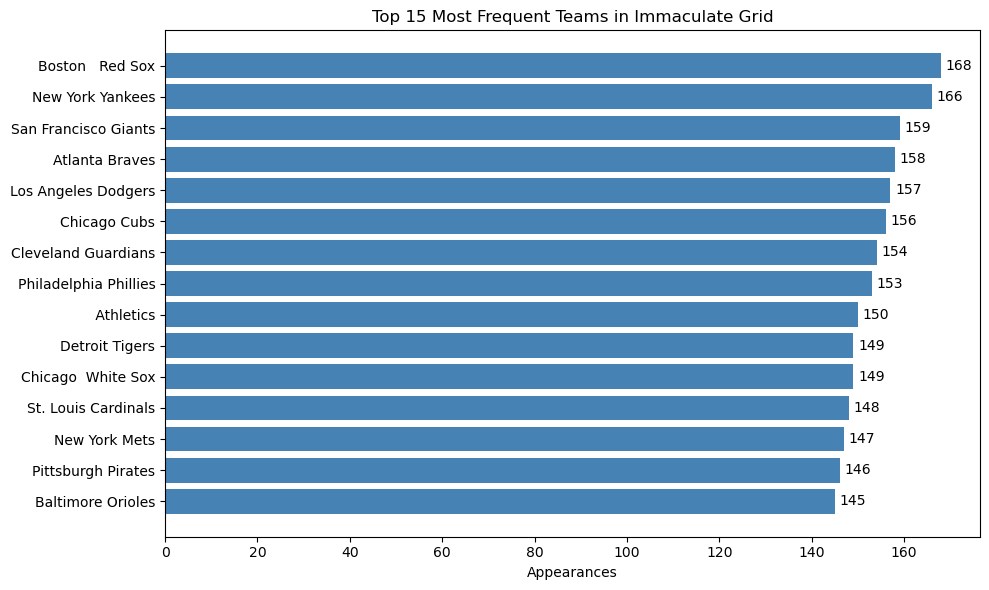

In [10]:
# Map codes to short names for cleaner plotting
code_to_name = teams.drop_duplicates('code').set_index('code')['label'].to_dict()

top15 = team_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top15)), top15.values, color='steelblue')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([code_to_name.get(c, c) for c in top15.index])
ax.invert_yaxis()
ax.set_xlabel('Appearances')
ax.set_title('Top 15 Most Frequent Teams in Immaculate Grid')

for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()

## Bottom 10 least frequent teams

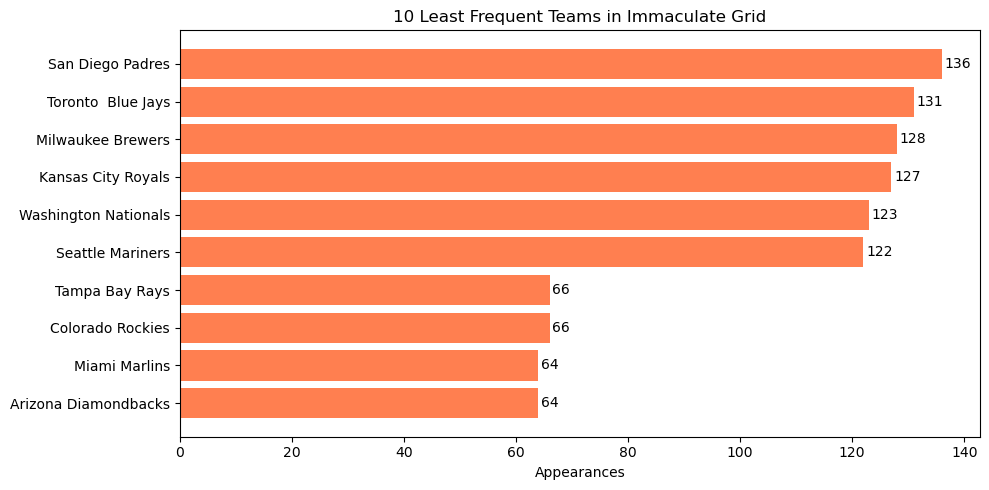

In [11]:
bottom10 = team_counts.tail(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(bottom10)), bottom10.values, color='coral')
ax.set_yticks(range(len(bottom10)))
ax.set_yticklabels([code_to_name.get(c, c) for c in bottom10.index])
ax.invert_yaxis()
ax.set_xlabel('Appearances')
ax.set_title('10 Least Frequent Teams in Immaculate Grid')

for bar, val in zip(bars, bottom10.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()

## Stat categories breakdown by group

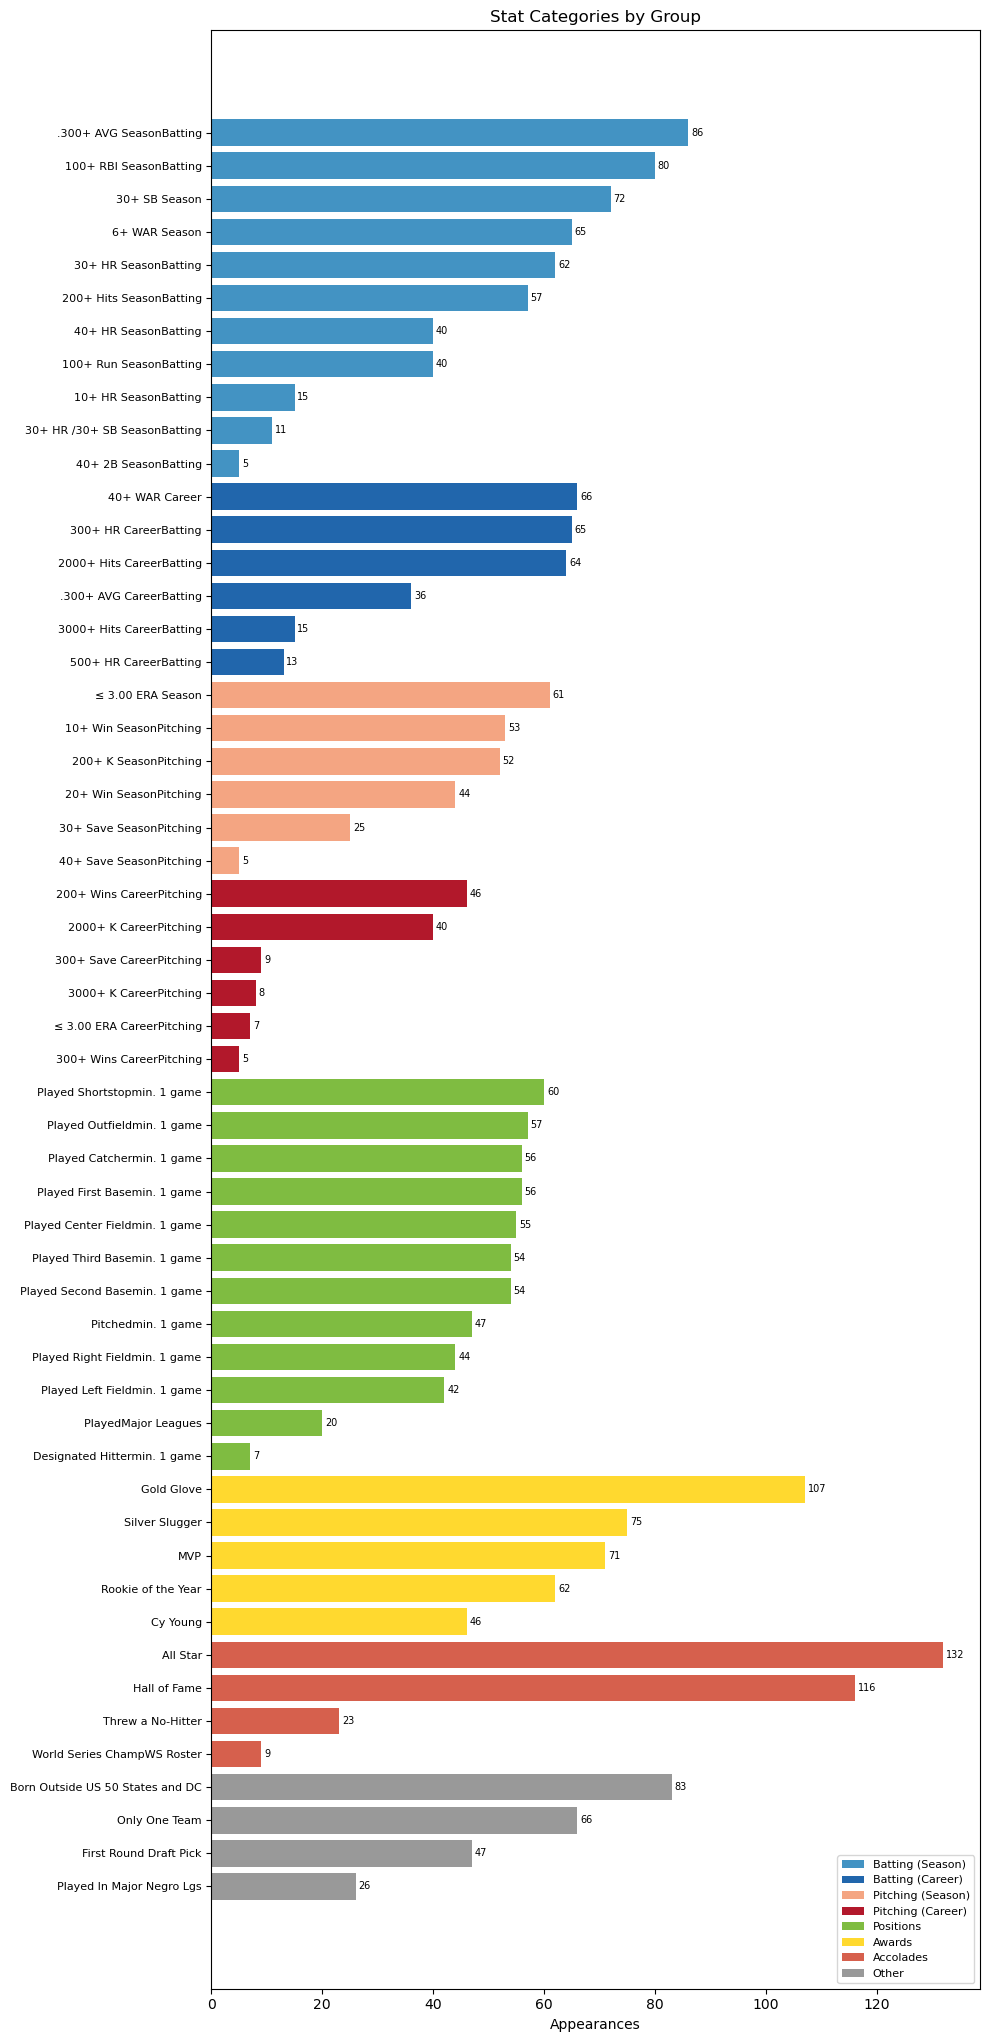

In [12]:
category_colors = {
    'Batting (Season)': '#4393c3',
    'Batting (Career)': '#2166ac',
    'Pitching (Season)': '#f4a582',
    'Pitching (Career)': '#b2182b',
    'Positions': '#7fbc41',
    'Awards': '#ffd92f',
    'Accolades': '#d6604d',
    'Other': '#999999',
}

cat_order = ['Batting (Season)', 'Batting (Career)', 'Pitching (Season)', 'Pitching (Career)',
             'Positions', 'Awards', 'Accolades', 'Other']
label_order = []
colors = []
for cat in cat_order:
    cat_labels = stats_cat[stats_cat['category'] == cat]['label'].value_counts()
    for lbl in cat_labels.index:
        label_order.append(lbl)
        colors.append(category_colors[cat])

counts_ordered = [stat_counts.get(l, 0) for l in label_order]

fig, ax = plt.subplots(figsize=(10, max(8, len(label_order) * 0.38)))
bars = ax.barh(range(len(label_order)), counts_ordered, color=colors)
ax.set_yticks(range(len(label_order)))
ax.set_yticklabels(label_order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Appearances')
ax.set_title('Stat Categories by Group')

for bar, val in zip(bars, counts_ordered):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=7)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=category_colors[c], label=c) for c in cat_order]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Grid composition: how many teams vs stats per grid?

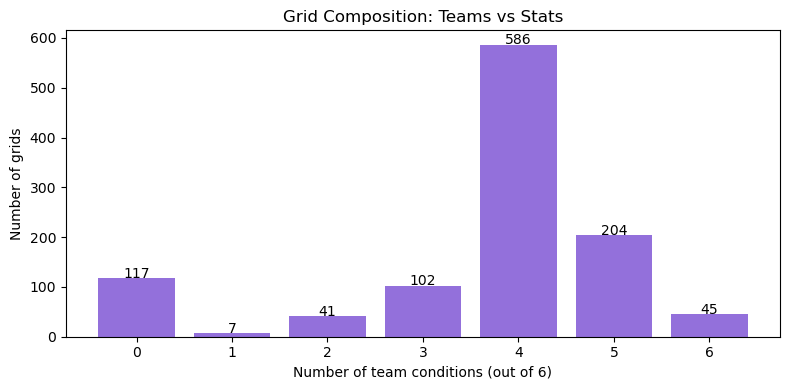

In [13]:
grid_team_count = conditions.groupby('grid_num')['type'].apply(lambda x: (x == 'team').sum())
composition = grid_team_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(composition.index, composition.values, color='mediumpurple')
ax.set_xlabel('Number of team conditions (out of 6)')
ax.set_ylabel('Number of grids')
ax.set_title('Grid Composition: Teams vs Stats')
ax.set_xticks(range(0, 7))

for x, y in zip(composition.index, composition.values):
    ax.text(x, y + 1, str(y), ha='center')

plt.tight_layout()
plt.show()

## Teams on rows vs columns

In [14]:
row_teams = teams[teams['axis'] == 'row']['code'].value_counts().rename('row_count')
col_teams = teams[teams['axis'] == 'col']['code'].value_counts().rename('col_count')

axis_df = pd.concat([row_teams, col_teams], axis=1).fillna(0).astype(int)
axis_df['total'] = axis_df['row_count'] + axis_df['col_count']
axis_df = axis_df.sort_values('total', ascending=False)
axis_df['name'] = axis_df.index.map(code_to_name)
axis_df.head(15)

,row_count,col_count,total,name
code,,,,
BOS,103,65,168,Boston Red Sox
NYY,101,65,166,New York Yankees
SFG,102,57,159,San Francisco Giants
ATL,88,70,158,Atlanta Braves
LAD,101,56,157,Los Angeles Dodgers
CHC,100,56,156,Chicago Cubs
CLE,95,59,154,Cleveland Guardians
PHI,87,66,153,Philadelphia Phillies
OAK,94,56,150,Athletics


## Most common team pairings (co-occurrences in the same grid)

In [15]:
from itertools import combinations

pair_counts = {}
for grid_num, group in teams.groupby('grid_num'):
    codes = sorted(group['code'].tolist())
    for a, b in combinations(codes, 2):
        pair = (a, b)
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

pairs_df = pd.DataFrame(
    [{'team_a': a, 'team_b': b, 'count': c} for (a, b), c in pair_counts.items()]
).sort_values('count', ascending=False)

pairs_df['team_a_name'] = pairs_df['team_a'].map(code_to_name)
pairs_df['team_b_name'] = pairs_df['team_b'].map(code_to_name)

print(f'{len(pairs_df)} unique team pairings\n')
pairs_df.head(20)

434 unique team pairings



,team_a,team_b,count,team_a_name,team_b_name
53,NYY,OAK,31,New York Yankees,Athletics
139,BAL,OAK,29,Baltimore Orioles,Athletics
138,BAL,CHW,28,Baltimore Orioles,Chicago White Sox
13,ATL,LAD,28,Atlanta Braves,Los Angeles Dodgers
220,CIN,SFG,27,Cincinnati Reds,San Francisco Giants
15,DET,LAD,27,Detroit Tigers,Los Angeles Dodgers
58,CLE,KCR,27,Cleveland Guardians,Kansas City Royals
45,CHW,PHI,26,Chicago White Sox,Philadelphia Phillies
62,HOU,SFG,25,Houston Astros,San Francisco Giants
186,SDP,SFG,25,San Diego Padres,San Francisco Giants


## Team appearance over time (rolling trend)

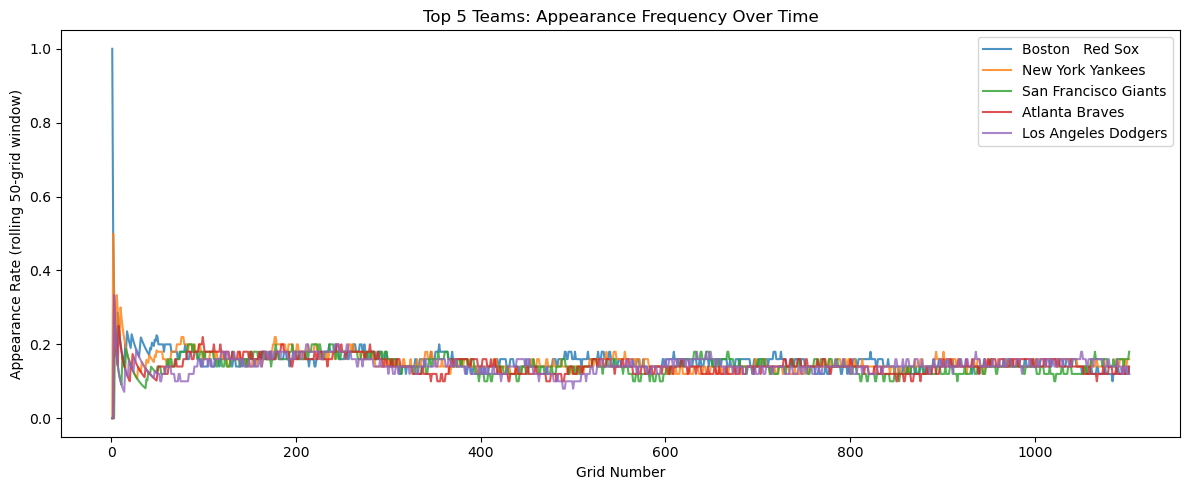

In [16]:
# Show top 5 teams' appearance density over grid numbers
top5_codes = team_counts.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
window = 50

for code in top5_codes:
    mask = teams[teams['code'] == code]['grid_num']
    presence = pd.Series(0, index=range(1, df['grid_num'].max() + 1))
    presence[mask.values] = 1
    rolling = presence.rolling(window, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, label=code_to_name.get(code, code), alpha=0.8)

ax.set_xlabel('Grid Number')
ax.set_ylabel(f'Appearance Rate (rolling {window}-grid window)')
ax.set_title('Top 5 Teams: Appearance Frequency Over Time')
ax.legend()
plt.tight_layout()
plt.show()